In [1]:
import pandas as pd

file_path = '../data/IMDB Dataset.csv'


df = pd.read_csv(file_path)

print("Dataset loaded successfully into a pandas DataFrame!")
      

Dataset loaded successfully into a pandas DataFrame!


In [2]:
# This gives us a snapshot of the data's structure, column names, and content
# without overwhelming us by trying to display all 50,000 rows.
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
# This is one of the most common commands to run immediately after loading data
# to get a high-level quantitative overview of the dataset.
df.shape

(50000, 2)

In [4]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [5]:

# counts the occurrences of each unique value ('positive' and 'negative'),
# and returns a new Series with the unique values as the index and their counts as the data.
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

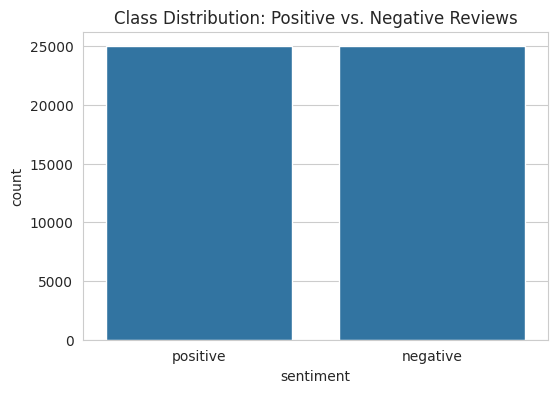

In [6]:
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set_style('whitegrid')

plt.figure(figsize=(6,4))
sns.countplot(x='sentiment' , data = df)

plt.title('Class Distribution: Positive vs. Negative Reviews')

plt.show()

In [7]:
def to_lowercase(text):
    return text.lower()

example_text = "This is a GREAT Project! and I'm REALLY enjoying it and learing a LOT from it."
cleaned_text = to_lowercase(example_text)

print("Original Text : ", example_text)
print("Lowercased Text: ", cleaned_text)

Original Text :  This is a GREAT Project! and I'm REALLY enjoying it and learing a LOT from it.
Lowercased Text:  this is a great project! and i'm really enjoying it and learing a lot from it.


In [8]:
df['review'] = df['review'].apply(to_lowercase)

print("DataFrame after applying the lowercase function:")
df.head()

DataFrame after applying the lowercase function:


,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [9]:
import re

def remove_html_tags(text):
    pattern = re.compile('<.*?>')
    return pattern.sub('',text)

example_text_with_html ="this was an <i>amazing</i> movie. i loved it! <br /><br />totally <b>worth</b> watching."
cleaned_text = remove_html_tags(example_text_with_html)

print("original text with HTML : ",example_text_with_html)
print("Text after HTML removal: ",cleaned_text)

original text with HTML :  this was an <i>amazing</i> movie. i loved it! <br /><br />totally <b>worth</b> watching.
Text after HTML removal:  this was an amazing movie. i loved it! totally worth watching.


In [10]:
df['review'] = df['review'].apply(remove_html_tags)

print("DataFrame after removing HTML tags:")
df.head()

DataFrame after removing HTML tags:


,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [11]:
import re 
def remove_punctuation(text):
    return re.sub(r'[^a-z0-9\s]','',text).strip()

example_text_with_punc = "wow... this movie was *amazing*! (10/10). i'd say it's a 'must-see'."
cleaned_text = remove_punctuation(example_text_with_punc)

print("Original Text with Punctuation: ", example_text_with_punc)
print("Text after Punctuation Removal:", cleaned_text)   

Original Text with Punctuation:  wow... this movie was *amazing*! (10/10). i'd say it's a 'must-see'.
Text after Punctuation Removal: wow this movie was amazing 1010 id say its a mustsee


In [12]:
df['review'] = df['review'].apply(remove_punctuation)

print("DataFrame after removing punctuation: ")
df.head()

DataFrame after removing punctuation: 


,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


In [13]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/gagan-
[nltk_data]     chandra/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
from nltk.corpus import stopwords

english_stopwords_list = stopwords.words('english')

print("---First 10 StopWords from NLTK List ---")
print(english_stopwords_list[:10])
print("\n" + "=" *50 + "\n")

stop_words_set = set(english_stopwords_list)


print(f"We have successfully loaded {len(stop_words_set)} English stopwords into a highly efficient set.")

---First 10 StopWords from NLTK List ---
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']


We have successfully loaded 198 English stopwords into a highly efficient set.


In [15]:
def tokenize_and_remove_stopwords(text):
    tokens = text.split()

    cleaned_tokens = [token for token in tokens if token not in stop_words_set]
    return cleaned_tokens

example_sentence = "this movie is just a brilliant and beautiful production"
cleaned_tokens_list = tokenize_and_remove_stopwords(example_sentence)

print("Original Sentence:", example_sentence)
print("Tokens after Stopword Removal:", cleaned_tokens_list)

Original Sentence: this movie is just a brilliant and beautiful production
Tokens after Stopword Removal: ['movie', 'brilliant', 'beautiful', 'production']


In [16]:
df['review'] = df['review'].apply(tokenize_and_remove_stopwords)

print("DataFrame after tokenization and stopword removal:")
df.head()

DataFrame after tokenization and stopword removal:


,review,sentiment
0,"[one, reviewers, mentioned, watching, 1, oz, e...",positive
1,"[wonderful, little, production, filming, techn...",positive
2,"[thought, wonderful, way, spend, time, hot, su...",positive
3,"[basically, theres, family, little, boy, jake,...",negative
4,"[petter, matteis, love, time, money, visually,...",positive


In [17]:
import nltk

nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /home/gagan-
[nltk_data]     chandra/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [18]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

print(f"The lemma for 'movies' is : {lemmatizer.lemmatize('movies')}")
print(f"The lemma for 'running' is : {lemmatizer.lemmatize('running')}")

The lemma for 'movies' is : movie
The lemma for 'running' is : running


In [19]:
def lemmatize_tokens(tokens):
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return lemmatized_tokens


example_tokens = ['movies', 'are', 'amazing', 'characters', 'were', 'running', 'studies']
lemmatized_example = lemmatize_tokens(example_tokens)

print("Original Tokens:", example_tokens)
print("Lemmatized Tokens:", lemmatized_example)

Original Tokens: ['movies', 'are', 'amazing', 'characters', 'were', 'running', 'studies']
Lemmatized Tokens: ['movie', 'are', 'amazing', 'character', 'were', 'running', 'study']


In [20]:
df['review'] = df['review'].apply(lemmatize_tokens)

print("DataFrame after applying the lemmatization funtion: ")
df.head()

DataFrame after applying the lemmatization funtion: 


,review,sentiment
0,"[one, reviewer, mentioned, watching, 1, oz, ep...",positive
1,"[wonderful, little, production, filming, techn...",positive
2,"[thought, wonderful, way, spend, time, hot, su...",positive
3,"[basically, there, family, little, boy, jake, ...",negative
4,"[petter, matteis, love, time, money, visually,...",positive


In [21]:
def join_tokens(tokens):
    return ' '.join(tokens)

example_lemmatized_tokens = ['movie', 'brilliant', 'beautiful', 'production', 'character', 'scene']
rejoined_text = join_tokens(example_lemmatized_tokens)

print("Original list of tokens:", example_lemmatized_tokens)
print("Rejoined string:", rejoined_text)

Original list of tokens: ['movie', 'brilliant', 'beautiful', 'production', 'character', 'scene']
Rejoined string: movie brilliant beautiful production character scene


In [22]:
df[ 'cleaned_review'] = df['review'].apply(join_tokens)

print("DataFrame after final cleaning and rejoining tokens: ")
df[['review','cleaned_review','sentiment']].head()

DataFrame after final cleaning and rejoining tokens: 


,review,cleaned_review,sentiment
0,"[one, reviewer, mentioned, watching, 1, oz, ep...",one reviewer mentioned watching 1 oz episode y...,positive
1,"[wonderful, little, production, filming, techn...",wonderful little production filming technique ...,positive
2,"[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...,positive
3,"[basically, there, family, little, boy, jake, ...",basically there family little boy jake think t...,negative
4,"[petter, matteis, love, time, money, visually,...",petter matteis love time money visually stunni...,positive


In [23]:
X = df['cleaned_review'] #Features

y = df['sentiment'] #Target

print("---Features---")
print(X.head())
print("---Target---")
print(y.head())

---Features---
0    one reviewer mentioned watching 1 oz episode y...
1    wonderful little production filming technique ...
2    thought wonderful way spend time hot summer we...
3    basically there family little boy jake think t...
4    petter matteis love time money visually stunni...
Name: cleaned_review, dtype: str
---Target---
0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: str


In [24]:
from sklearn.model_selection import train_test_split


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2 ,random_state = 42, stratify = y)

print("Shape of X_train : ", X_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_train : ", y_train.shape)
print("Shape of y_train : ", y_test.shape)

Shape of X_train :  (40000,)
Shape of X_test:  (10000,)
Shape of y_train :  (40000,)
Shape of y_train :  (10000,)


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [28]:
tfidf_vectorizer = TfidfVectorizer(max_features=10000)

print("TfidfVectorizer initialized successfully:")
print(tfidf_vectorizer)

TfidfVectorizer initialized successfully:
TfidfVectorizer(max_features=10000)


In [29]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Let's confirm that the operation is complete.
print("Successfully fitted the vectorizer and transformed the training data.")

Successfully fitted the vectorizer and transformed the training data.


In [30]:
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Let's confirm that the operation is complete.
print("Successfully transformed the testing data.")


Successfully transformed the testing data.


In [31]:
# First, let's check the shape of our training data matrix.
print("Shape of the TF-IDF training data matrix (X_train_tfidf):", X_train_tfidf.shape)

# Next, we check the shape of our testing data matrix.
print("Shape of the TF-IDF testing data matrix (X_test_tfidf):", X_test_tfidf.shape)

Shape of the TF-IDF training data matrix (X_train_tfidf): (40000, 10000)
Shape of the TF-IDF testing data matrix (X_test_tfidf): (10000, 10000)


In [32]:
from sklearn.linear_model import LogisticRegression